In [ ]:
# This notebook demonstrates how to use the mass difference clustering method in deltamsi to cluster ions based on their mass differences 
# and their cosine colocalization scores, and to visualize the results. The mass difference clustering method is a powerful tool for identifying groups of ions that are related by specific mass differences
# (e.g., due to common biochemical transformations or adducts), and for annotating these mass differences using a mass difference database. 
# In this example, we will use a mass difference database that contains the most common mass differences between metabolites from the COCONUT database, weighted by their frequency in the database.
#  We will then visualize the clustering results and explore the local neighborhood of a specific ion of interest in the mass difference graph.
# Note: the specific parameters and settings used in this notebook (e.g., tolerance for mass differences, weighting scheme for edges, clustering resolution) are just examples, and you may need to adjust them based on the characteristics of your dataset and your analysis goals.

In [1]:
import deltamsi
from deltamsi.core.msicube import MSICube
import matplotlib.pyplot as plt

In [ ]:
#replace "/directory/containing/imzml/data" with the directory containing the imzml data of the METASPACE dataset : ds=2025-06-29_18h35m36s 

In [ ]:
# compute mean spectra for each sample and globally, then pick peaks on the global mean spectrum.
cube = MSICube(data_directory="/directory/containing/imzml/data",imzml_layer="RAW")
cube.compute_mean_spectra(scope = "samples" ,mode="centroid",mass_accuracy_ppm=None, tolerance_da =0.0005 , min_mz=100.0, max_mz=2200, binning_p=0.0001 )
cube.compute_mean_spectra(scope = "global",tic_normalize=False)
cube.pick_peaks(topn=3000,binning_p=0.0001,distance_ppm=10)

INFO: MSICube initialized with 1 samples found.
INFO: Calculating mean spectrum for: pseudomonas_colonies (Mode: centroid)
INFO: Mean spectra calculated and stored.
INFO: Computing global mean spectrum...
INFO: Global mean spectrum calculated and stored in adata.uns['mean_spectrum_global'].
INFO: Starting peak picking on the global mean spectrum.
INFO: Peak picking finished. 3000 mz selected.
INFO: Selected mz values stored in adata.var and adata.uns['peak_picking_options'].


In [ ]:
# extract the ion images for the picked peaks with a tolerance of 10 ppm.
cube.extract_matrix(tol_ppm=10)

INFO: Starting extraction of peak intensity matrix (X) for all samples.
INFO: Extracting matrix for sample: pseudomonas_colonies
INFO: Concatenating data from all samples...
INFO: Extraction complete. Final shape: (6372, 3000) (Pixels x Peaks). Data stored in adata.X, adata.obsm['spatial'], adata.obs['sample'].


In [ ]:
# visualize the ion image for m/z 538.5 with a tolerance of 10 ppm.
cube.save()

INFO: AnnData saved to /home/rlarocca20/msi_data/pseudo_small/adata.h5ad (format=h5ad).


'/home/rlarocca20/msi_data/pseudo_small/adata.h5ad'

In [2]:
import deltamsi
from deltamsi.core.msicube import MSICube
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# laod the data
cube = MSICube("/directory/containing/imzml/data")
cube.load()

INFO: MSICube initialized with 1 samples found.
INFO: AnnData loaded from /home/rlarocca20/msi_data/pseudo_small/adata.h5ad (format=h5ad).


AnnData object with n_obs × n_vars = 6372 × 3000
    obs: 'sample'
    var: 'mz'
    uns: 'matrix_extraction_options', 'mean_spectra', 'mean_spectra_options', 'mean_spectra_samples', 'mean_spectrum_global', 'mean_spectrum_global_options', 'peak_picking_options'
    obsm: 'spatial'
    layers: 'RAW'

In [4]:
# clip the intensities below 100000 and move them to a new layer called "clip", then compute the spatial chaos scores on the "clip" layer.
cube.clip_or_mask_intensities(low=100000, layer = "RAW", low_action="move", output_layer="clip")
cube.compute_spatial_chaos_scores(obsm_key="spatial", sample_key="sample",layer="clip")

array([[0.98958509],
       [0.98024718],
       [0.43643411],
       ...,
       [0.88519683],
       [0.89806184],
       [0.85072684]])

In [5]:
# filter the ions based on their spatial chaos scores (e.g., keep ions with mean chaos score >= 0.5)
# spatial chaos scores: shape (n_vars, n_samples)
chaos = cube.adata.varm["spatial_chaos"]

# Example: keep ions with mean chaos score >= 0.5 (adjust threshold to your needs)
mean_chaos = np.nanmax(chaos, axis=1)
keep_mask = mean_chaos >= 0.5

# Subset AnnData along vars (ions)
cube.adata = cube.adata[:, keep_mask].copy()

In [6]:
# apply a 2D median filter with a window size of 3 to the "RAW" layer and save the result in a new layer called "median_filter_2d".
cube.msi_median_filter_2d(layer="RAW",output_layer="median_filter_2d",size=3)

In [7]:
# apply a quantile thresholding to the "median_filter_2d" layer, keeping only the pixels with intensities above the 97th percentile, and save the result in a new layer called "threshold_quantile". Then, cap the hotspots in the "threshold_quantile" layer by setting all pixel intensities above the 3rd percentile to the value of the 3rd percentile, and save the result in a new layer called "im_process".
cube.msi_threshold_quantile(layer="median_filter_2d",output_layer="threshold_quantile",q=0.03)
cube.msi_cap_hotspots(layer="threshold_quantile",output_layer="im_process",q=0.97)

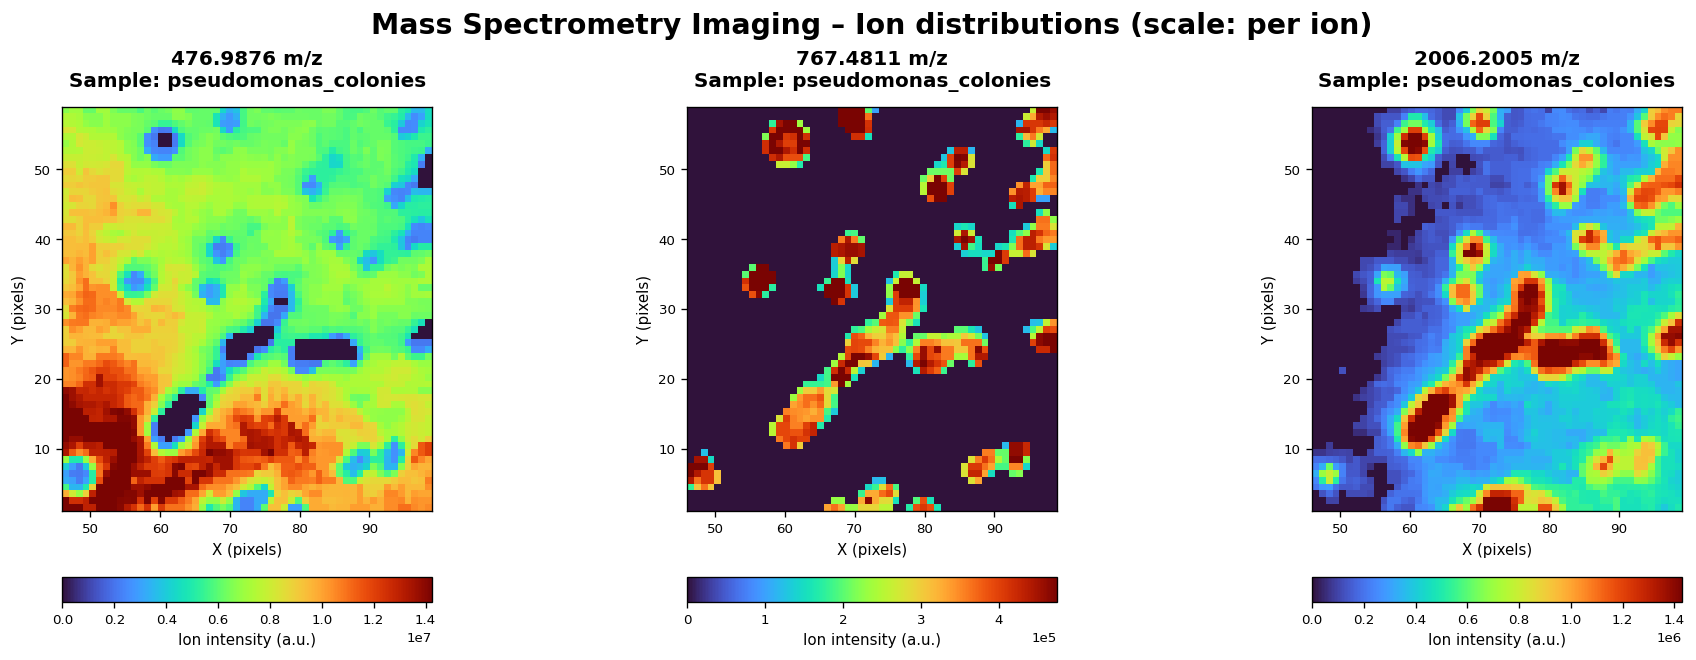

In [8]:
# visualize the ion images for m/z 476.3133, 767.5464, and 2000 with a tolerance of 10 ppm on the "im_process" layer, using per-ion scaling.
cube.plot_ion_images(mz=[476.3133,767.5464,2000], scale_mode="per_ion",layer = "im_process")

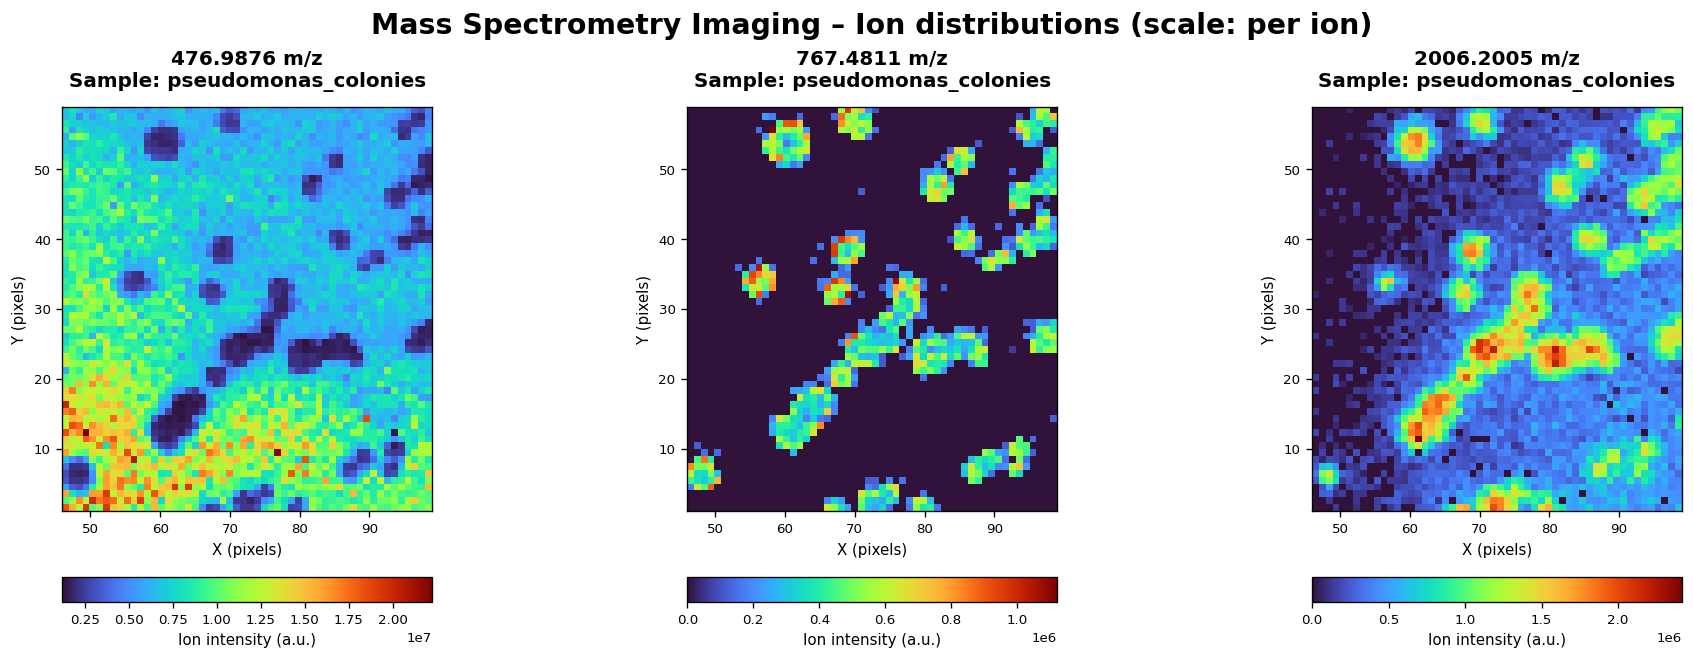

In [9]:
cube.plot_ion_images(mz=[476.3133,767.5464,2000], scale_mode="per_ion",layer = "RAW")

In [10]:
# scale the intensities in the "RAW" layer using z-score scaling and save the result in a new layer called "scale".
cube.scale_zscore(mode = "all",layer="RAW",output_layer = "scale")

In [11]:
# this will compute the cosine similarity between the ion images in the "im_process" layer, excluding self-colocalization, and store the results in varp under the key "ion_cosine".
from deltamsi.processing.colocalization import CosineColocParams
S = cube.compute_cosine_colocalization(params=CosineColocParams(layer = "im_process", mode="dense", include_self=False, store_varp_key="ion_cosine"))

In [12]:
# cluster the ions based on their cosine colocalization scores, keeping only the ions with a mean cosine similarity above 0.7, and store the cluster labels in var under the key "coloc_cluster".
from deltamsi.params.options import (MassClusteringOptions,)
options_clustering = MassClusteringOptions(method = "colocalization",output_col="coloc_cluster", resolution=1, knn_k=200, return_graph=False)
cube.cluster_masses(options= options_clustering,keep_mask = S >0.7)

INFO: Starting clustering on 2612 masses (Resolution: 1, Method: colocalization)...
INFO: Clustering complete: 7 clusters found.


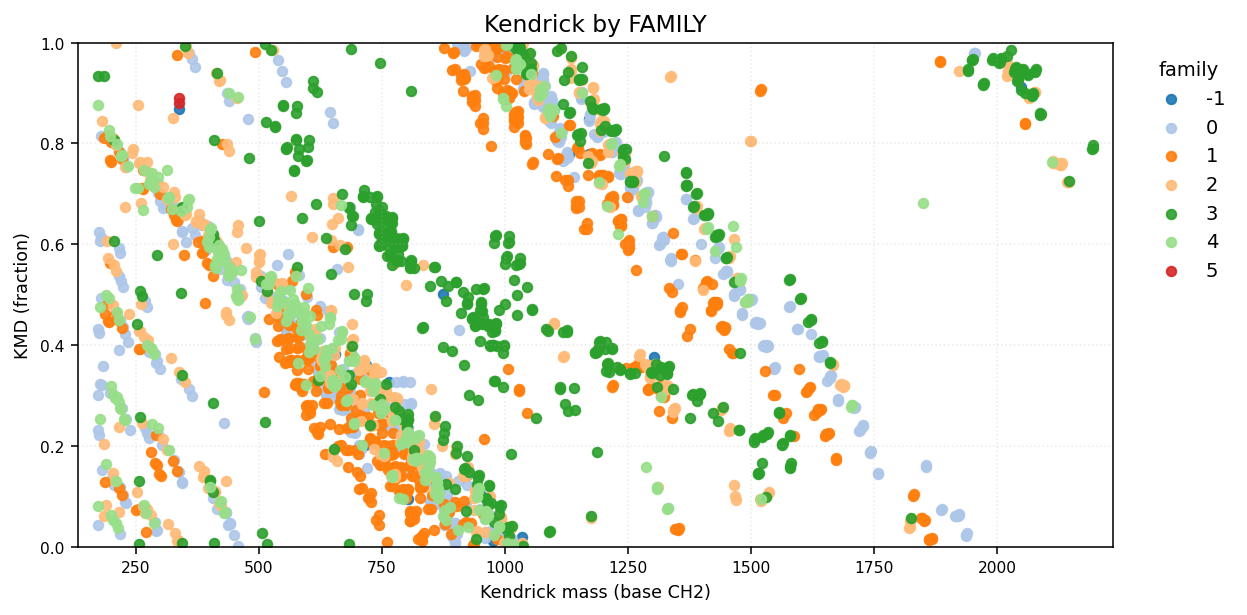

In [13]:
# visualize the clustering results using the "coloc_cluster" column in var.
cube.plot_kendrick(top_k_clusters=10,two_panels=False,label_col="coloc_cluster")
plt.show()

In [14]:
# aggregate the ion images by the "coloc_cluster" labels, using the mean as the aggregation function, and save the results in obsm under the key "coloc_agg". Then, visualize the aggregated ion images for the top 5 clusters.
cube.aggregate_vars_by_label( label_col="coloc_cluster" ,obsm_key="coloc_agg",layer ="scale" )

Index(['0', '4', '3', '2', '1', '-1', '5'], dtype='object', name='coloc_cluster')

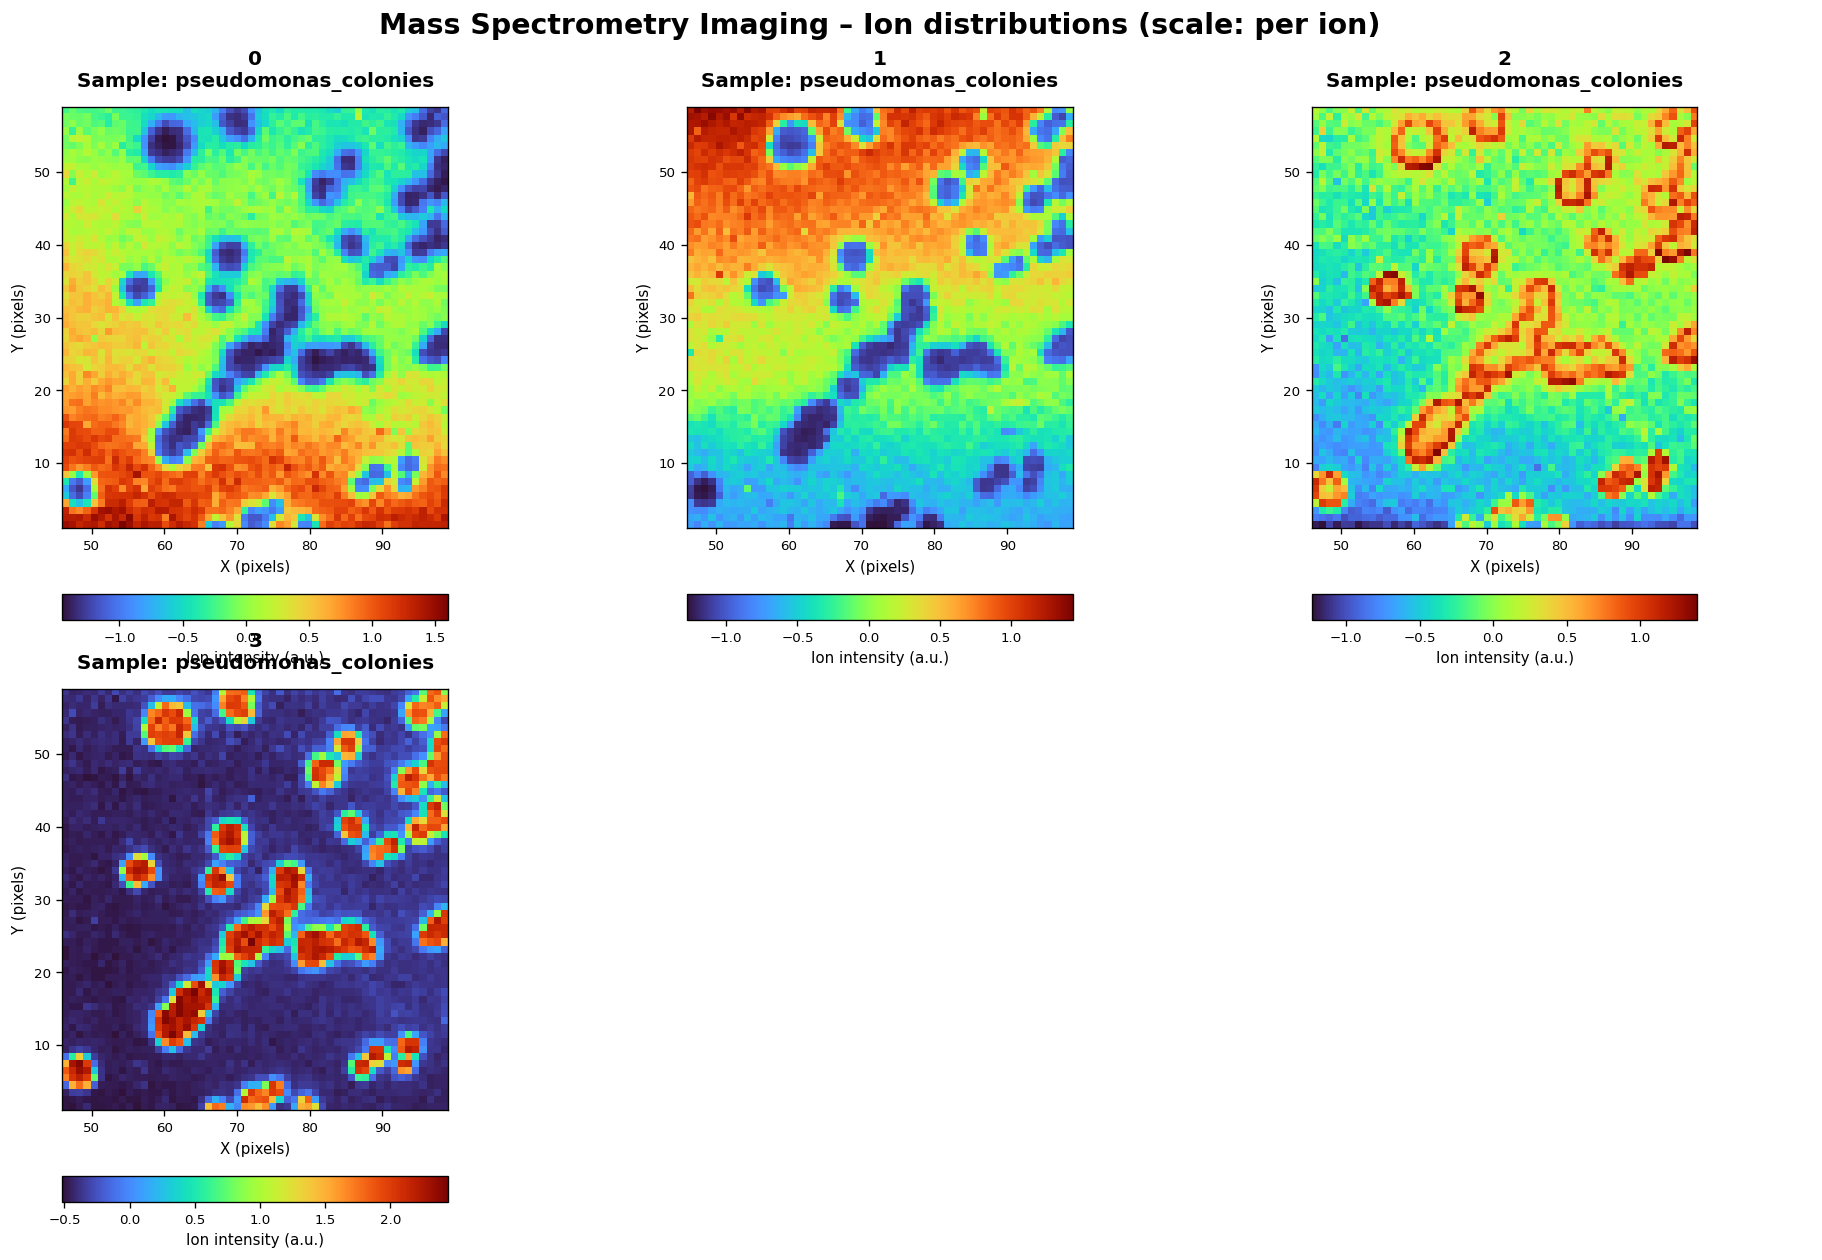

In [15]:
# visualize the aggregated ion images for the top 5 clusters.
cube.plot_ion_images(mz=["0","1","2","3"],obsm_key="coloc_agg",scale_mode ="per_ion")

In [ ]:
# load the mass difference database and append some additional mass differences to it.
# the mass difference database is a csv file with three columns: "delta_da", "label", and "score". The "delta_da" column contains the mass differences
# in daltons, the "label" column contains the annotation for the mass difference, and the "score" column contains a score for the mass difference (e.g., based on its frequency in a reference database). You can replace the additional mass differences with your own values and labels as needed.
# Note: the mass difference database is used for annotating the mass differences between the cluster centers and the picked peaks, so make sure to include the relevant mass differences for your dataset and analysis goals.
# CCBF_200_L1_massweighted is a mass difference database that contains the most common mass differences between metabolites from the COCONUT database, weighted by their frequency in the database. You can use this database as a starting point for annotating the mass differences in your dataset, and then add any additional mass differences that are relevant to your analysis.
import pandas as pd
mass_diff = pd.read_csv("./CCBF_200_L1_massweighted.csv")
mass_diffdb = mass_diff[["delta_da","label","score"]].copy()
rows = []
rows.append({"delta_da": 1.00335, "label": "13C-12C", "score": 1})
rows.append({"delta_da": 2.00670, "label": "13C2-12C2", "score": 1})
rows.append({"delta_da": 2.00425, "label": "18O-16O", "score": 1})
rows.append({"delta_da": 15.97394, "label": "K-Na", "score": 1})
rows.append({"delta_da": 21.98194, "label": "Na-H", "score": 1})
rows.append({"delta_da": 37.95588, "label": "K-H", "score": 1})
rows.append({"delta_da": 189.04259, "label": "C10H7NO3", "score": 1})

mass_diffdb  = pd.concat([mass_diffdb , pd.DataFrame(rows)], ignore_index=True)

In [18]:
# scale the intensities in the "RAW" layer using z-score scaling and save the result in a new layer called "scale".
cube.scale_zscore(mode = "all",layer="RAW",output_layer = "scale")

In [20]:
# compute the cosine similarity between the ion images in the "im_process" layer, excluding self-colocalization, and store the results in varp under the key "ion_cosine".
from deltamsi.processing.colocalization import CosineColocParams
S = cube.compute_cosine_colocalization(params=CosineColocParams(layer = "im_process", mode="dense", include_self=False, store_varp_key="ion_cosine"))

In [25]:
# cluster the ions based on their mass differences  and their cosine colocalization scores, keeping only the ions with a mean cosine similarity above 0.5, and store the cluster labels in var under the key "mass_cluster". The mass differences between the cluster centers and the picked peaks are annotated using the mass difference database loaded earlier.
# Note: the clustering method used here is based on a graph of mass differences, where the edges between the ions are defined based on the mass differences between their m/z values and the mass differences in the mass difference database. The weights of the edges are defined based on the scores in the mass difference database and the cosine colocalization scores between the ions. You can adjust the parameters of the clustering method (e.g., tolerance for mass differences, weighting scheme for edges, clustering resolution) to better suit your dataset and analysis goals.
from deltamsi.params.options import (MassClusteringOptions,)
options_clustering = MassClusteringOptions(tol_da=0.001, tol_ppm=None, edge_max_delta_m=200, delta_col='delta_da', score_col='score', output_col="mass_cluster"  , label_col='label', resolution=1, weight_transform='inv1p', weight_kwargs={}, knn_k=100, knn_mode='union', return_graph=False)
cube.cluster_masses(candidates_df=mass_diffdb,options= options_clustering,keep_mask = S >0.5)

INFO: Starting clustering on 2612 masses (Resolution: 1, Method: candidates)...
INFO: Clustering complete: 125 clusters found.


(<Figure size 1680x840 with 1 Axes>,
 [<Axes: title={'center': 'Kendrick by FAMILY'}, xlabel='Kendrick mass (base CH2)', ylabel='KMD (fraction)'>],
              mz  cluster family  kendrick_mass  kmd_fraction  kmd_defect
 0      173.4254       -1     -1     173.231750      0.231751         NaN
 1      173.6262       -1     -1     173.432327      0.432327         NaN
 2      174.1280       -1     -1     173.933563      0.933566         NaN
 3      174.2374       -1     -1     174.042847      0.042844         NaN
 4      174.2749       -1     -1     174.080307      0.080302         NaN
 ...         ...      ...    ...            ...           ...         ...
 2084  2080.2715       18     18    2077.948730      0.948641         NaN
 2085  2088.1886       18     18    2085.856934      0.856900         NaN
 2086  2090.1933       18     18    2087.859375      0.859362         NaN
 2087  2144.1175       -1     -1    2141.723389      0.723349         NaN
 2088  2197.2507       18     18    21

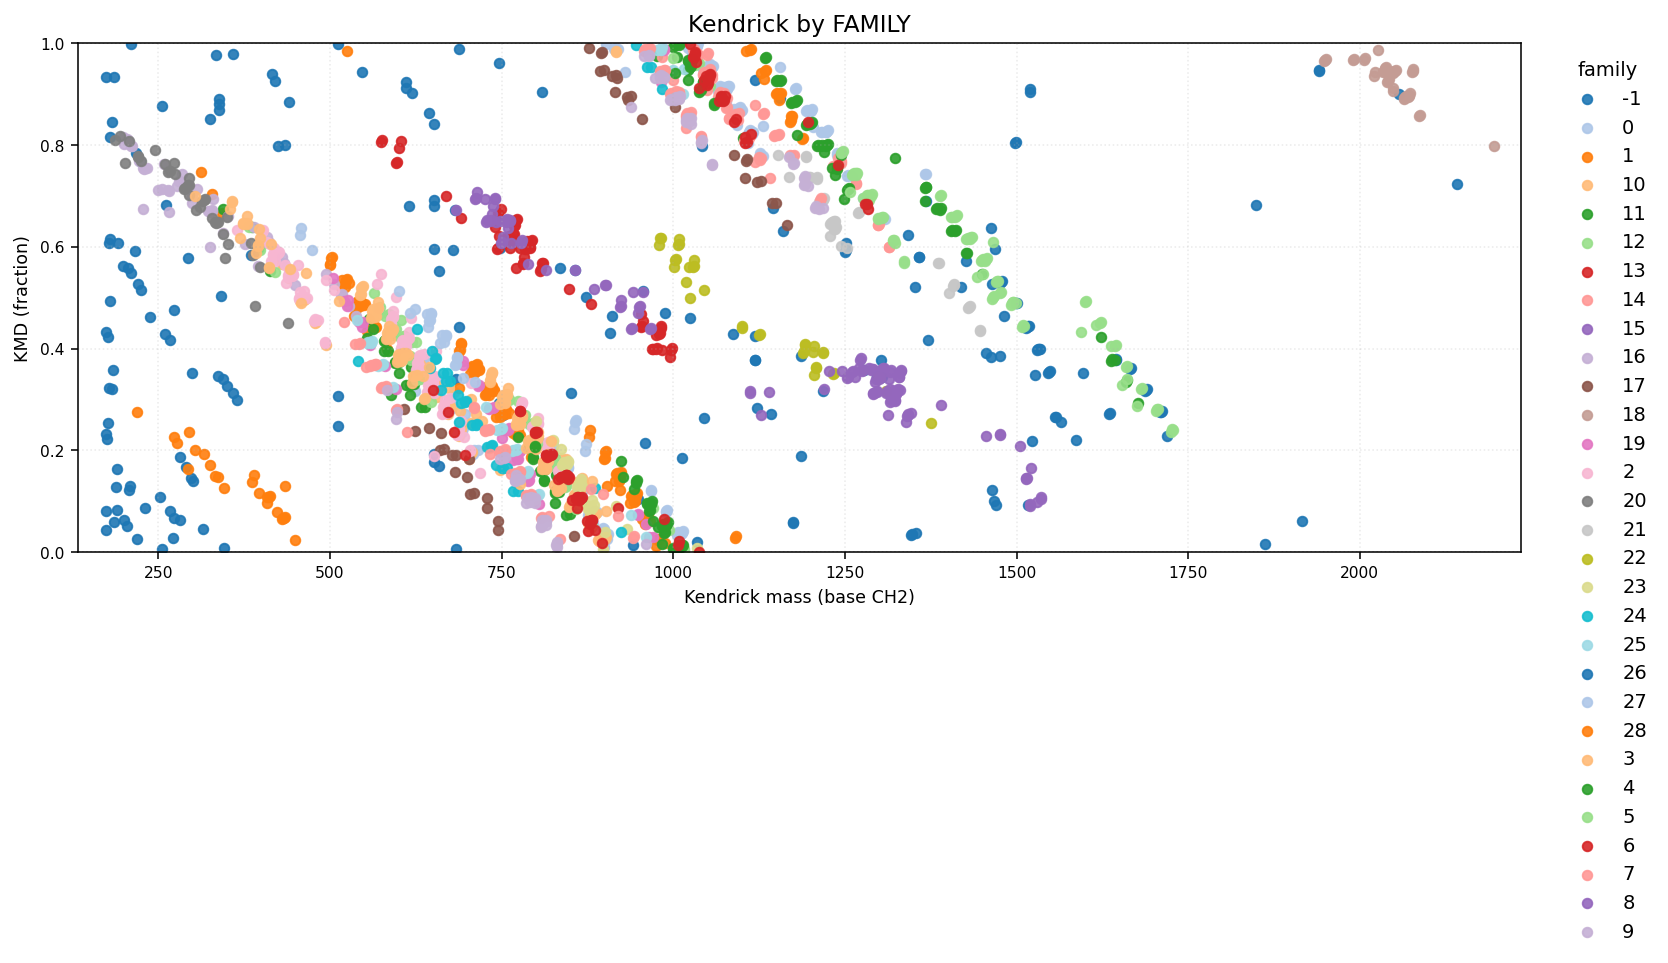

In [26]:
# visualize the clustering results using the "mass_cluster" column in var.
cube.plot_kendrick(top_k_clusters=30,two_panels=False,label_col="mass_cluster",figsize=(12, 6) )

In [27]:
# aggregate the ion images by the "mass_cluster" labels, using the mean as the aggregation function, and save the results in obsm under the key "masscl_agg". Then, visualize the aggregated ion images for the top 5 clusters.
cube.aggregate_vars_by_label( label_col="mass_cluster" ,obsm_key="masscl_agg",layer ="scale" )

Index(['-1', '89', '32', '86', '91', '70', '87', '20', '69', '95',
       ...
       '117', '42', '18', '82', '41', '118', '119', '64', '43', '120'],
      dtype='object', name='mass_cluster', length=125)

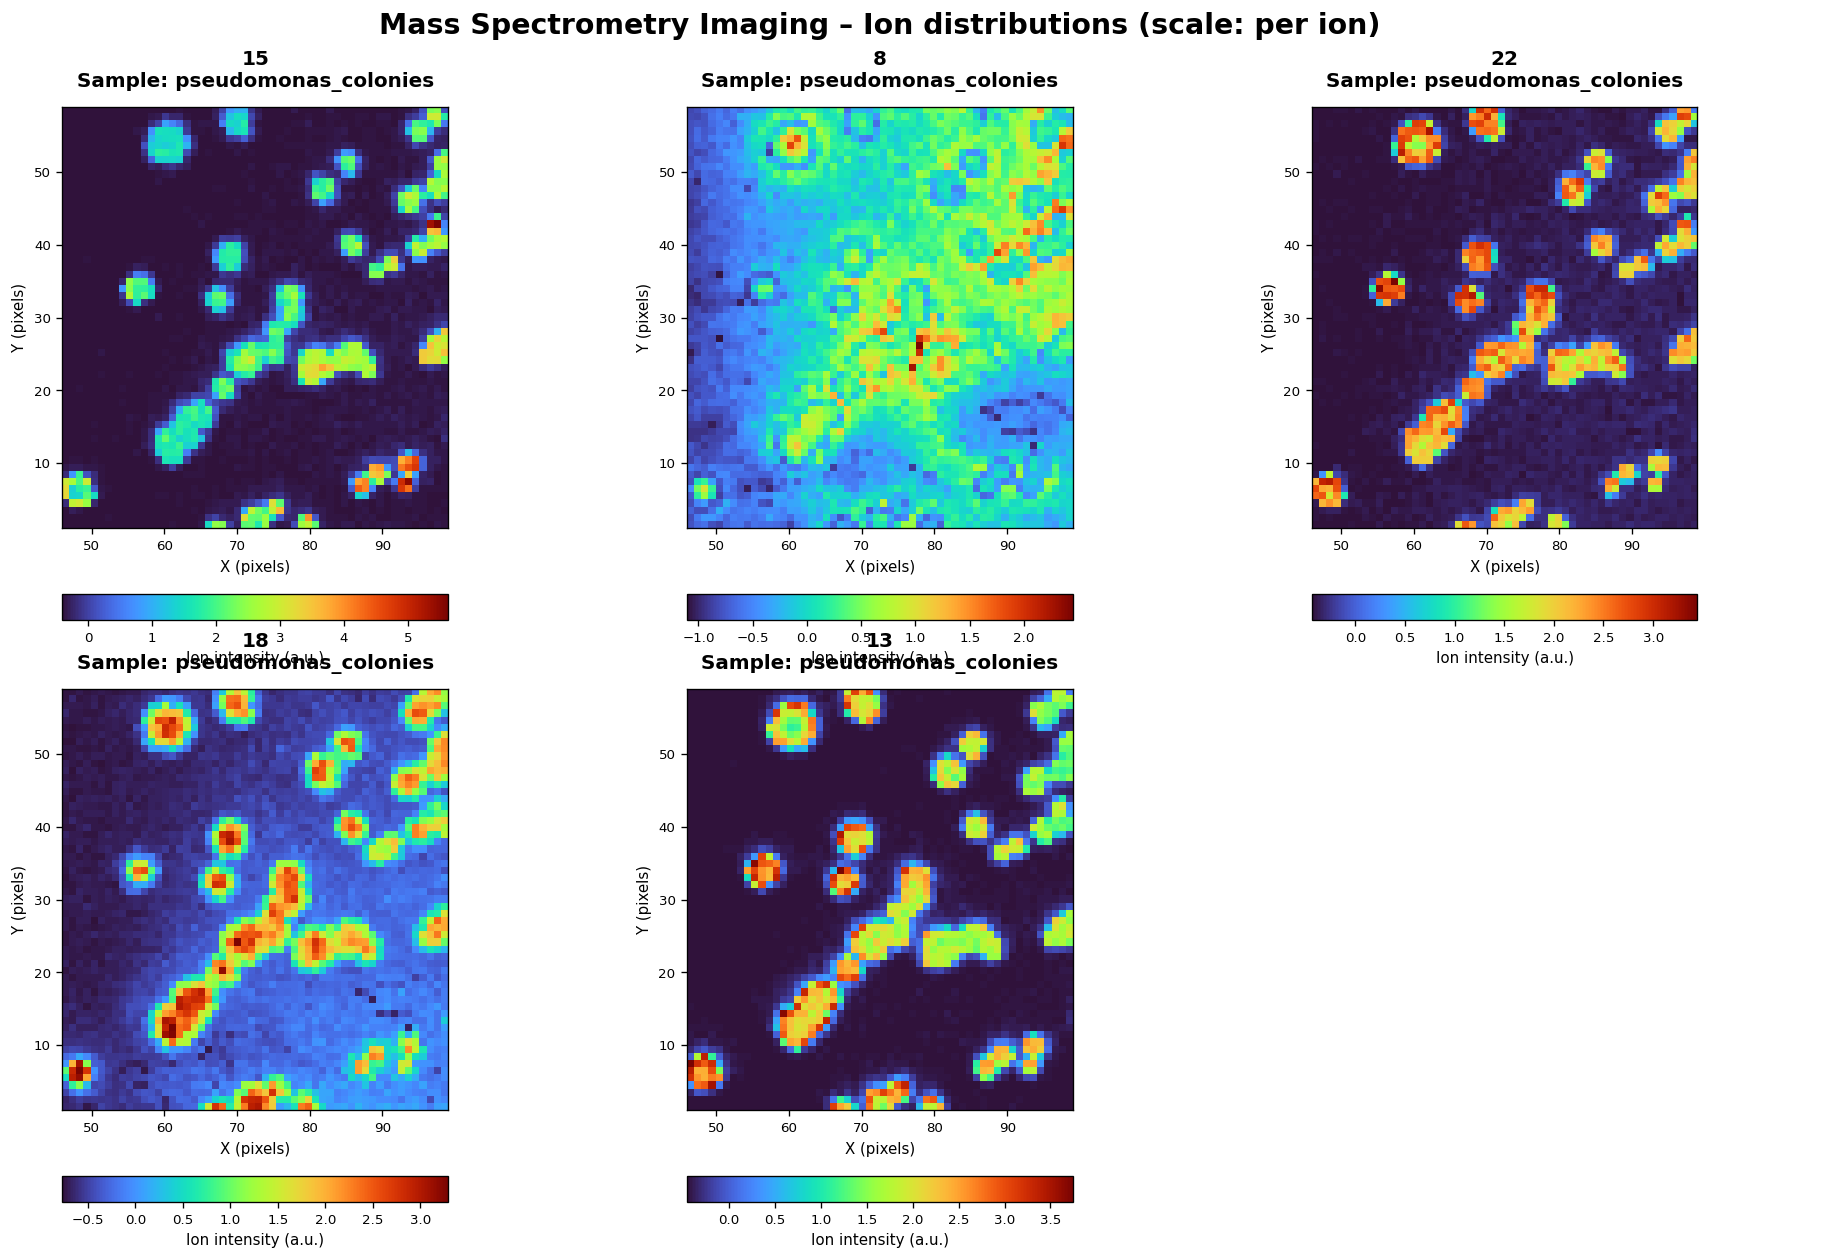

In [32]:
# visualize the aggregated ion images for the top 5 clusters.
cube.plot_ion_images(mz=['15',"8","22","18","13"],obsm_key="masscl_agg",scale_mode ="per_ion")

In [38]:
cube.adata.var.loc[cube.adata.var["mass_cluster"]==8].sort_values("mdg_degree",ascending=False)

,mz,coloc_cluster,mdg_degree,mdg_wdegree,mass_cluster
feature_id,,,,,
mz_2539_1303.8101,1303.8101,2,12,2.258966,8
mz_2543_1304.8144,1304.8144,2,9,1.868958,8
mz_2485_1273.8005,1273.8005,2,9,0.681035,8
mz_2557_1312.7821,1312.7821,2,8,0.809348,8
mz_2534_1301.7935,1301.7935,2,8,2.048004,8
...,...,...,...,...,...
mz_2591_1333.8473,1333.8473,3,1,0.500000,8
mz_2403_1228.7283,1228.7283,3,1,0.037016,8
mz_2547_1306.8210,1306.8210,2,1,0.500000,8


In [ ]:
# orfamide B: [C63H112N10O17 + Na]⁺ 1303.8099 central node of cluster 8 with 12 edges

In [ ]:

# orfamide B: [C63H112N10O17 + Na]⁺ 1303.8099 central node of cluster 8 with 12 edges
# direct_mass_neighbors allows you to retrieve the direct neighbors of a given ion in the mass difference graph, along with their cosine colocalization scores and the annotations of the mass differences between the central ion and its neighbors.
# This allow you to explore the local neighborhood of a given ion of interest in the mass difference graph, and to see how it is connected to other ions based on their mass differences and colocalization patterns. You can use this information to generate hypotheses about the potential annotations of the ions in the neighborhood, and to guide further analysis and validation steps.
mn_col = ['src_pos', 'dst_pos', 'cosine_ion_cosine',
       'mz_i', 'mz_j', 'dm', 'cand_delta', 'cand_label','err', 'dst_mass_cluster',
       'dst_mdg_degree']

out = cube.direct_mass_neighbors("mz_2539_1303.8101",mass_uns_key = "mass_clustering",cosine_key = "ion_cosine")
out[mn_col]

,src_pos,dst_pos,cosine_ion_cosine,mz_i,mz_j,dm,cand_delta,cand_label,err,dst_mass_cluster,dst_mdg_degree
0,2180,2183,0.998529,1303.8101,1304.8144,1.0043,1.003350,13C-12C,0.000950,8,9
1,2180,2218,0.993130,1303.8101,1325.7919,21.9818,21.981940,Na-H,0.000140,8,7
2,2180,2239,0.984148,1303.8101,1341.7652,37.9551,37.955880,K-H,0.000780,8,4
3,2180,2135,0.973699,1273.8005,1303.8101,30.0096,30.010565,C+1 H+2 O+1,0.000965,8,9
4,2180,2177,0.888343,1301.7935,1303.8101,2.0166,2.015650,H+2,0.000950,8,8
5,2180,2115,0.817090,1261.7636,1303.8101,42.0465,42.046950,C+3 H+6,0.000450,8,6
6,2180,2225,0.800508,1303.8101,1331.8053,27.9952,27.994915,C+1 O+1,0.000285,8,6
7,2180,2168,0.751509,1297.7639,1303.8101,6.0462,6.046950,H+6,0.000750,8,8
8,2180,2204,0.702055,1303.8101,1317.8256,14.0155,14.015650,C+1 H+2,0.000150,8,6
9,2180,2200,0.677318,1303.8101,1315.8103,12.0002,12.000000,C+1,0.000200,8,5
